# Neumann Boundary Condition: Convergence & Error Analysis

This notebook provides a detailed analysis of the Poisson solver's performance specifically for Neumann boundary conditions. It compares different azimuthal meshing strategies and quadrature rules, focusing on convergence and error visualization.

In [14]:
import os, sys
import pandas as pd

# Setup path to project root
repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    render_table2_accuracy,
    render_table2_runtime,
    run_and_plot_errors_vary_m,
    plot_convergence
)

## Test Configuration

We will fix the angular resolution `N` and vary the radial resolution `M` to observe convergence.

In [15]:
# Fixed angular resolution
N_fixed = 32
# Varying radial resolutions
M_values = [32, 64, 128, 256]

MUTE_OUTPUT = False

# --- Method Definitions ---

# Methods for Jittered Grid Comparison
METHODS_JITTERED = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
    dict(name="Fixed-jittered-NUDFT", label="Fixed jittered / NUDFT", azu_unif=1, mesh_kind="jittered", solver_azu_unif=1, use_nudft=True),
    dict(name="Fixed-jittered-NUFFT", label="Fixed jittered / NUFFT", azu_unif=1, mesh_kind="jittered", solver_azu_unif=1, use_nudft=False),
]

# Methods for Random Grid Comparison
METHODS_RANDOM = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
    dict(name="Fixed-rand-NUDFT", label="Fixed rand / NUDFT", azu_unif=1, mesh_kind="rand", solver_azu_unif=1, use_nudft=True),
    dict(name="Fixed-rand-NUFFT", label="Fixed rand / NUFFT", azu_unif=1, mesh_kind="rand", solver_azu_unif=1, use_nudft=False),
]

# Methods for All Grid Types Comparison
METHODS_ALL_GRIDS = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
]
for kind in ("rand", "jittered", "clustered", "sine"):
    METHODS_ALL_GRIDS += [
        dict(name=f"Fixed-{kind}-NUDFT", label=f"Fixed {kind} / NUDFT", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, use_nudft=True),
        dict(name=f"Fixed-{kind}-NUFFT", label=f"Fixed {kind} / NUFFT", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, use_nudft=False),
    ]

## Run Test Pipelines

We execute the test pipelines and filter the results to include only the Neumann cases (`bc_choice=2`).

In [16]:
print("Running Neumann Error Analysis for Jittered Grid...")
df_jittered_raw = run_tests_pipeline(None, M_values, fixed_other=N_fixed, methods=METHODS_JITTERED, test_type="P1_Table2", mute=MUTE_OUTPUT)
df_jittered = df_jittered_raw[df_jittered_raw['bc'] == 2].copy()

print("\nRunning Neumann Error Analysis for Random Grid...")
df_random_raw = run_tests_pipeline(None, M_values, fixed_other=N_fixed, methods=METHODS_RANDOM, test_type="P1_Table2", mute=MUTE_OUTPUT)
df_random = df_random_raw[df_random_raw['bc'] == 2].copy()

print("\nRunning Neumann Error Analysis for All Grid Types...")
df_all_grids_raw = run_tests_pipeline(None, M_values, fixed_other=N_fixed, methods=METHODS_ALL_GRIDS, test_type="P1_Table2", mute=MUTE_OUTPUT)
df_all_grids = df_all_grids_raw[df_all_grids_raw['bc'] == 2].copy()

print("\nAll tests completed.")

Running Neumann Error Analysis for Jittered Grid...

Uniform / FFT
  M=  32, Trapezoidal, Dirichlet | L2_rel=1.098e-05 | t=0.003s
  M=  32, Trapezoidal, Neumann | L2_rel=1.881e-04 | t=0.001s
  M=  32, Simpson, Dirichlet | L2_rel=3.139e-06 | t=0.005s
  M=  32, Simpson, Neumann | L2_rel=3.182e-06 | t=0.004s
  M=  64, Trapezoidal, Dirichlet | L2_rel=2.661e-06 | t=0.003s
  M=  64, Trapezoidal, Neumann | L2_rel=4.550e-05 | t=0.003s
  M=  64, Simpson, Dirichlet | L2_rel=4.023e-07 | t=0.009s
  M=  64, Simpson, Neumann | L2_rel=4.047e-07 | t=0.009s
  M= 128, Trapezoidal, Dirichlet | L2_rel=6.548e-07 | t=0.002s
  M= 128, Trapezoidal, Neumann | L2_rel=1.119e-05 | t=0.004s
  M= 128, Simpson, Dirichlet | L2_rel=5.085e-08 | t=0.016s
  M= 128, Simpson, Neumann | L2_rel=5.099e-08 | t=0.012s


C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Docume

  M= 256, Trapezoidal, Dirichlet | L2_rel=1.624e-07 | t=0.005s
  M= 256, Trapezoidal, Neumann | L2_rel=2.776e-06 | t=0.007s
  M= 256, Simpson, Dirichlet | L2_rel=6.388e-09 | t=0.032s
  M= 256, Simpson, Neumann | L2_rel=6.397e-09 | t=0.025s

Fixed jittered / NUDFT
  M=  32, Trapezoidal, Dirichlet | L2_rel=1.098e-05 | t=0.006s
  M=  32, Trapezoidal, Neumann | L2_rel=1.969e-04 | t=0.004s
  M=  32, Simpson, Dirichlet | L2_rel=3.139e-06 | t=0.008s
  M=  32, Simpson, Neumann | L2_rel=5.405e-05 | t=0.006s


C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]


  M=  64, Trapezoidal, Dirichlet | L2_rel=2.661e-06 | t=0.008s
  M=  64, Trapezoidal, Neumann | L2_rel=7.045e-05 | t=0.006s
  M=  64, Simpson, Dirichlet | L2_rel=4.023e-07 | t=0.011s
  M=  64, Simpson, Neumann | L2_rel=5.228e-05 | t=0.010s
  M= 128, Trapezoidal, Dirichlet | L2_rel=6.548e-07 | t=0.012s
  M= 128, Trapezoidal, Neumann | L2_rel=5.366e-05 | t=0.009s
  M= 128, Simpson, Dirichlet | L2_rel=5.084e-08 | t=0.021s
  M= 128, Simpson, Neumann | L2_rel=5.206e-05 | t=0.022s


...

C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]


  M= 128, Simpson, Neumann | L2_rel=2.603e-04 | t=1.370s
  M= 256, Trapezoidal, Dirichlet | L2_rel=1.071e-03 | t=3.292s
  M= 256, Trapezoidal, Neumann | L2_rel=2.606e-04 | t=2.838s


C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]


  M= 256, Simpson, Dirichlet | L2_rel=1.071e-03 | t=2.867s
  M= 256, Simpson, Neumann | L2_rel=2.602e-04 | t=2.761s

All tests completed.


C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]


---

## Analysis 1: Jittered Grid Convergence (Neumann)

In [17]:
render_table2_accuracy(df_jittered, title_prefix=f"Neumann Accuracy on Jittered Grid (N={N_fixed})")
render_table2_runtime(df_jittered, title_prefix=f"Neumann Runtime on Jittered Grid (N={N_fixed})")


Neumann Accuracy on Jittered Grid (N=32) Accuracy



Neumann Runtime on Jittered Grid (N=32) Runtime (s)


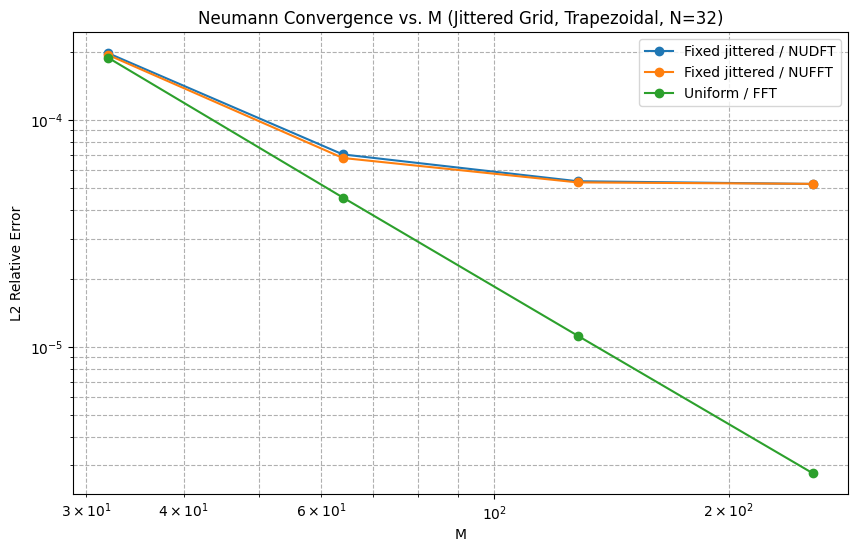

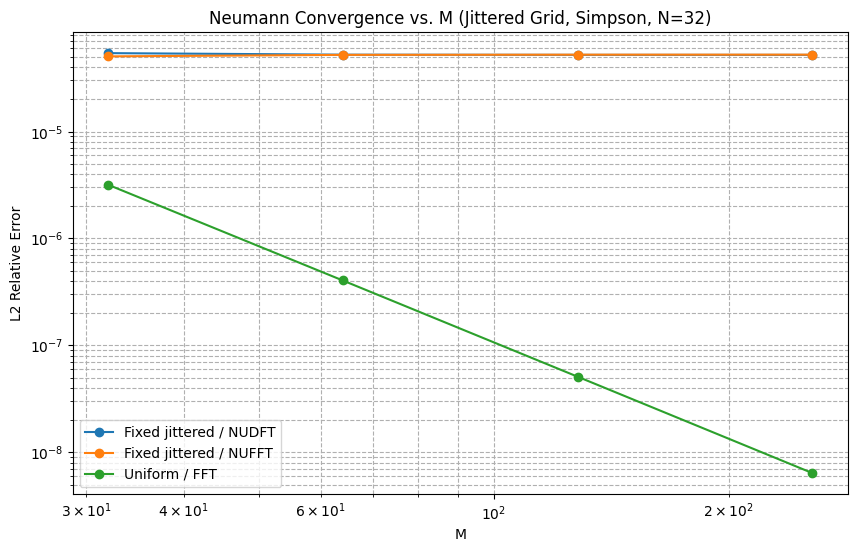

In [18]:
plot_convergence(
    df_jittered[df_jittered['quad'] == 1],
    x_axis='M',
    title=f'Neumann Convergence vs. M (Jittered Grid, Trapezoidal, N={N_fixed})',
    log_x=True, log_y=True
)

plot_convergence(
    df_jittered[df_jittered['quad'] == 2],
    x_axis='M',
    title=f'Neumann Convergence vs. M (Jittered Grid, Simpson, N={N_fixed})',
    log_x=True, log_y=True
)

---

## Analysis 2: Random Grid Convergence (Neumann)

In [19]:
render_table2_accuracy(df_random, title_prefix=f"Neumann Accuracy on Random Grid (N={N_fixed})")
render_table2_runtime(df_random, title_prefix=f"Neumann Runtime on Random Grid (N={N_fixed})")


Neumann Accuracy on Random Grid (N=32) Accuracy



Neumann Runtime on Random Grid (N=32) Runtime (s)


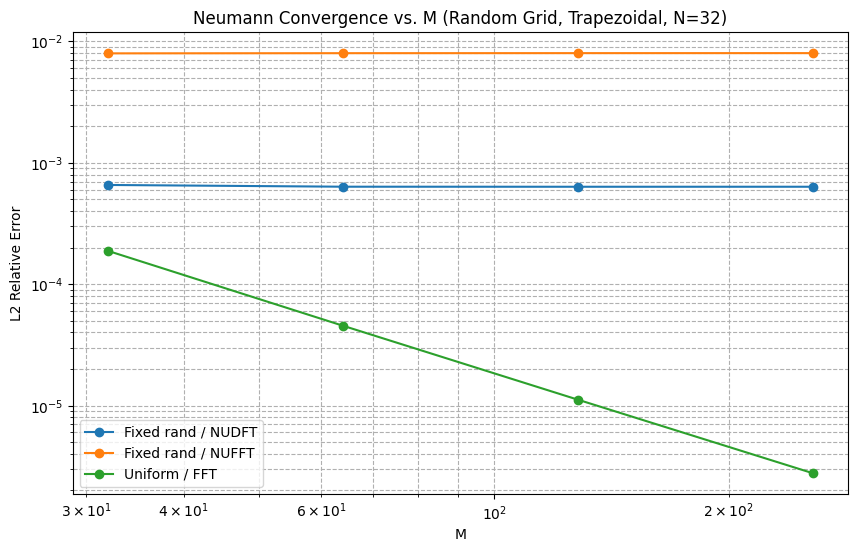

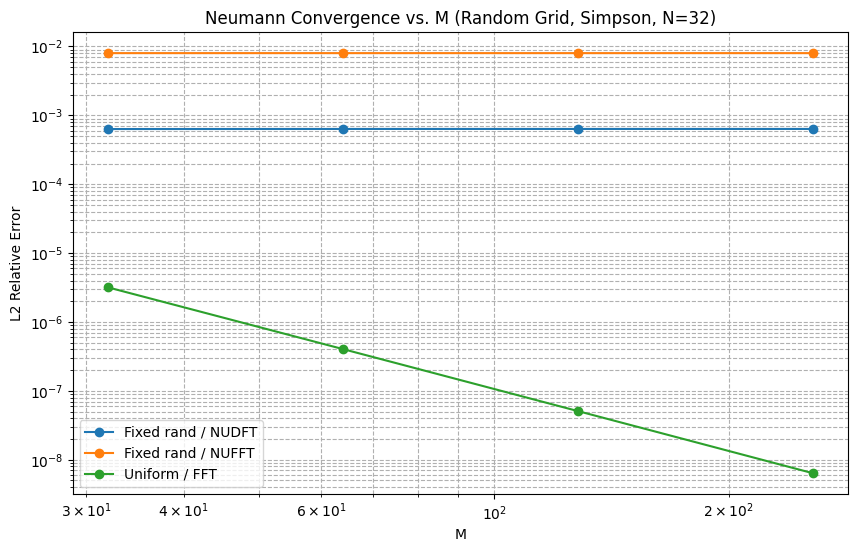

In [20]:
plot_convergence(
    df_random[df_random['quad'] == 1],
    x_axis='M',
    title=f'Neumann Convergence vs. M (Random Grid, Trapezoidal, N={N_fixed})',
    log_x=True, log_y=True
)

plot_convergence(
    df_random[df_random['quad'] == 2],
    x_axis='M',
    title=f'Neumann Convergence vs. M (Random Grid, Simpson, N={N_fixed})',
    log_x=True, log_y=True
)

---

## Analysis 3: All Grid Types Comparison (Neumann, Trapezoidal)

In [21]:
# To keep the table and plot cleaner, we will only compare the Trapezoidal rule results here
df_all_grids_trap = df_all_grids[df_all_grids['quad'] == 1]

render_table2_accuracy(df_all_grids_trap, title_prefix=f"Neumann Accuracy Across Grids (N={N_fixed}, Trapezoidal)")


Neumann Accuracy Across Grids (N=32, Trapezoidal) Accuracy


label,Uniform / FFT,Fixed clustered / NUDFT,Fixed jittered / NUDFT,Fixed rand / NUDFT,Fixed sine / NUDFT,Fixed clustered / NUFFT,Fixed jittered / NUFFT,Fixed rand / NUFFT,Fixed sine / NUFFT
quad_str,Trapezoidal,Trapezoidal,Trapezoidal,Trapezoidal,Trapezoidal,Trapezoidal,Trapezoidal,Trapezoidal,Trapezoidal
bc_str,Neumann,Neumann,Neumann,Neumann,Neumann,Neumann,Neumann,Neumann,Neumann
M,,,,,,,,,
32,1.88e-04,1.89e-04,1.97e-04,6.57e-04,1.87e-04,1.20e-03,1.93e-04,7.97e-03,3.44e-04
64,4.55e-05,5.33e-05,7.05e-05,6.35e-04,4.66e-05,1.22e-03,6.80e-05,8.00e-03,2.71e-04
128,1.12e-05,3.14e-05,5.37e-05,6.35e-04,1.66e-05,1.23e-03,5.30e-05,8.01e-03,2.62e-04
256,2.78e-06,2.99e-05,5.22e-05,6.35e-04,1.29e-05,1.23e-03,5.23e-05,8.01e-03,2.61e-04


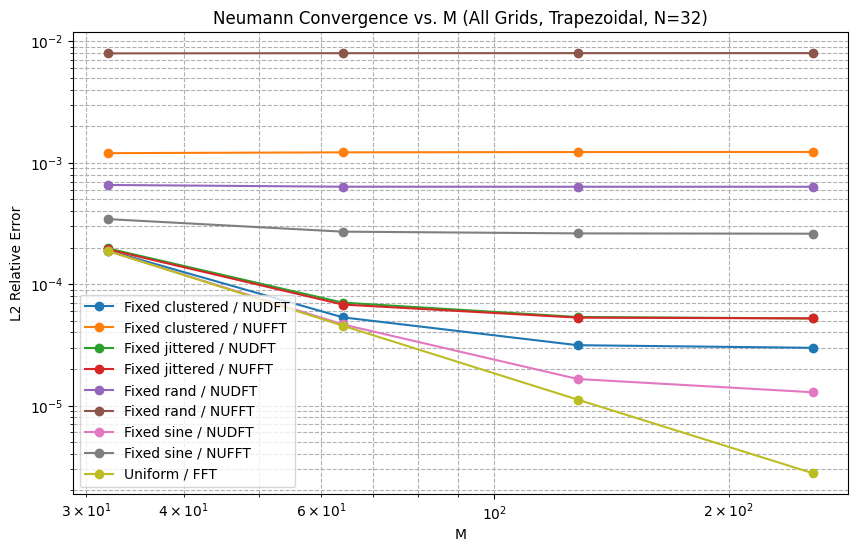

In [22]:
plot_convergence(
    df_all_grids_trap,
    x_axis='M',
    title=f'Neumann Convergence vs. M (All Grids, Trapezoidal, N={N_fixed})',
    log_x=True, log_y=True
)

---

## Detailed Error Visualization

Finally, we visualize the solution and pointwise error for a single, high-resolution case to get a qualitative sense of the error distribution.

Visualizing a high-resolution case for Uniform/FFT with Neumann BC and Simpson's rule.


C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Docume

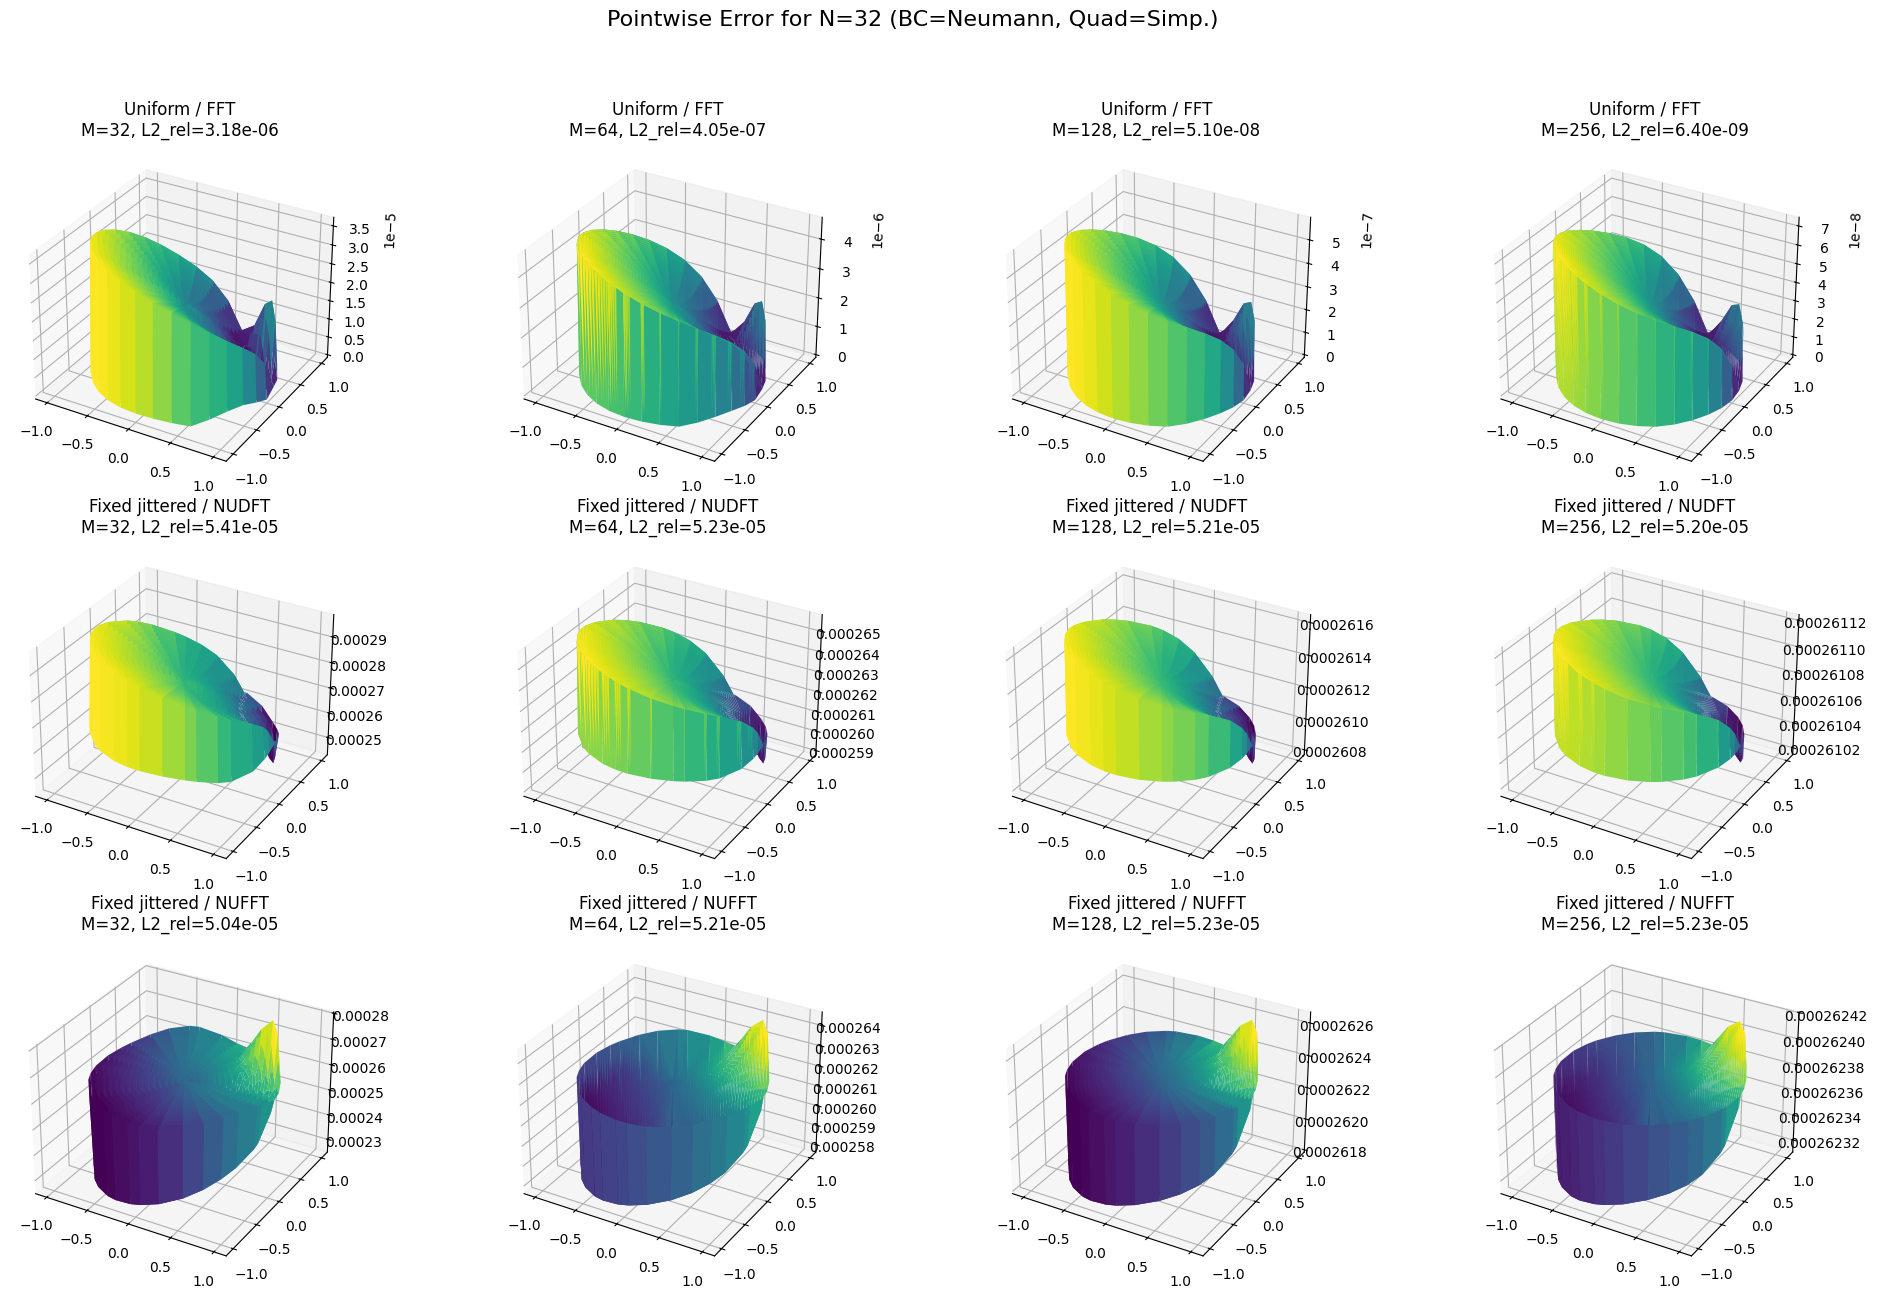

In [23]:
print("Visualizing a high-resolution case for Uniform/FFT with Neumann BC and Simpson's rule.")

run_and_plot_errors_vary_m(N_fixed, M_values, METHODS_JITTERED, bc_choice=2, quad_rule=2)
